# IEEE 33-Bus Simulation — EDA
**Comparing `simulation_with_der.csv` vs `simulation_no_der.csv`**


## Period
Jul 1–28 2024, 5-min intervals

DER buses: **17** (0.5 MW), **24** (0.4 MW), **32** (0.6 MW)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

DATA_DIR  = os.path.dirname(os.path.abspath('__file__'))
DER_BUSES = [17, 24, 32]
ZONES     = {'zone1': list(range(0,9)), 'zone2': list(range(9,18)),
             'zone3': list(range(18,25)), 'zone4': list(range(25,33))}
ZONE_COLORS = {'zone1':'#1f77b4','zone2':'#ff7f0e','zone3':'#2ca02c','zone4':'#d62728'}

print('Libraries loaded.')

Libraries loaded.


## 1  Load Data

In [3]:
df_der  = pd.read_csv(os.path.join(DATA_DIR, 'simulation_with_der.csv'), parse_dates=['timestamp'])
df_nder = pd.read_csv(os.path.join(DATA_DIR, 'simulation_no_der.csv'),   parse_dates=['timestamp'])

print(f'With-DER shape   : {df_der.shape}')
print(f'No-DER  shape    : {df_nder.shape}')
print(f'\nDate range       : {df_der.timestamp.min()} → {df_der.timestamp.max()}')
print(f'Timesteps        : {len(df_der):,}')
print(f'NaN (with DER)   : {df_der.isna().sum().sum()}')
print(f'NaN (no  DER)    : {df_nder.isna().sum().sum()}')

With-DER shape   : (8064, 133)
No-DER  shape    : (8064, 133)

Date range       : 2024-07-01 00:00:00 → 2024-07-28 23:55:00
Timesteps        : 8,064
NaN (with DER)   : 0
NaN (no  DER)    : 0


In [4]:
# Helper: extract a feature across all buses into a (n_steps, 33) DataFrame
def get_feature(df, feat):  # feat = 'V', 'P', 'Q', 'THETA'
    cols = [f'{feat}_bus{b}' for b in range(33)]
    return df[cols].copy().set_axis(range(33), axis=1)

# Add time features (shared index)
for df in (df_der, df_nder):
    df['hour']    = df['timestamp'].dt.hour + df['timestamp'].dt.minute / 60
    df['weekday'] = df['timestamp'].dt.weekday
    df['date']    = df['timestamp'].dt.date

V_der  = get_feature(df_der,  'V')
V_nder = get_feature(df_nder, 'V')
P_der  = get_feature(df_der,  'P')
P_nder = get_feature(df_nder, 'P')
Q_der  = get_feature(df_der,  'Q')
Q_nder = get_feature(df_nder, 'Q')

print('Feature matrices ready.')

Feature matrices ready.


## 2  Summary Statistics

In [5]:
summary_rows = []
for bus in range(33):
    v_d  = V_der[bus]
    v_nd = V_nder[bus]
    summary_rows.append({
        'bus': bus,
        'zone': next(z for z,bs in ZONES.items() if bus in bs),
        'has_DER': bus in DER_BUSES,
        'V_mean_noDER': v_nd.mean(),
        'V_mean_DER':   v_d.mean(),
        'V_delta_mean': (v_d - v_nd).mean(),
        'V_min_noDER':  v_nd.min(),
        'V_min_DER':    v_d.min(),
        'V_max_DER':    v_d.max(),
        'V_std_DER':    v_d.std(),
        'V_viol_noDER': (v_nd < 0.95).sum(),
        'V_viol_DER':   (v_d  < 0.95).sum(),
    })

summary = pd.DataFrame(summary_rows).set_index('bus')
pd.set_option('display.float_format', '{:.5f}'.format)
summary[['zone','has_DER','V_mean_noDER','V_mean_DER','V_delta_mean',
         'V_min_DER','V_viol_noDER','V_viol_DER']]

,zone,has_DER,V_mean_noDER,V_mean_DER,V_delta_mean,V_min_DER,V_viol_noDER,V_viol_DER
bus,,,,,,,,
0,zone1,False,1.00000,1.00000,0.00000,1.00000,0,0
1,zone1,False,0.99817,0.99853,0.00036,0.99783,0,0
2,zone1,False,0.98948,0.99176,0.00228,0.98754,0,0
3,zone1,False,0.98489,0.98823,0.00334,0.98210,0,0
4,zone1,False,0.98036,0.98479,0.00443,0.97672,0,0
5,zone1,False,0.96909,0.97591,0.00682,0.96336,0,0
6,zone1,False,0.96696,0.97404,0.00708,0.96082,0,0
7,zone1,False,0.96399,0.97200,0.00801,0.95730,0,0
8,zone1,False,0.96016,0.96951,0.00935,0.95276,540,0


## 3  System-Wide Voltage — Time Series Overview

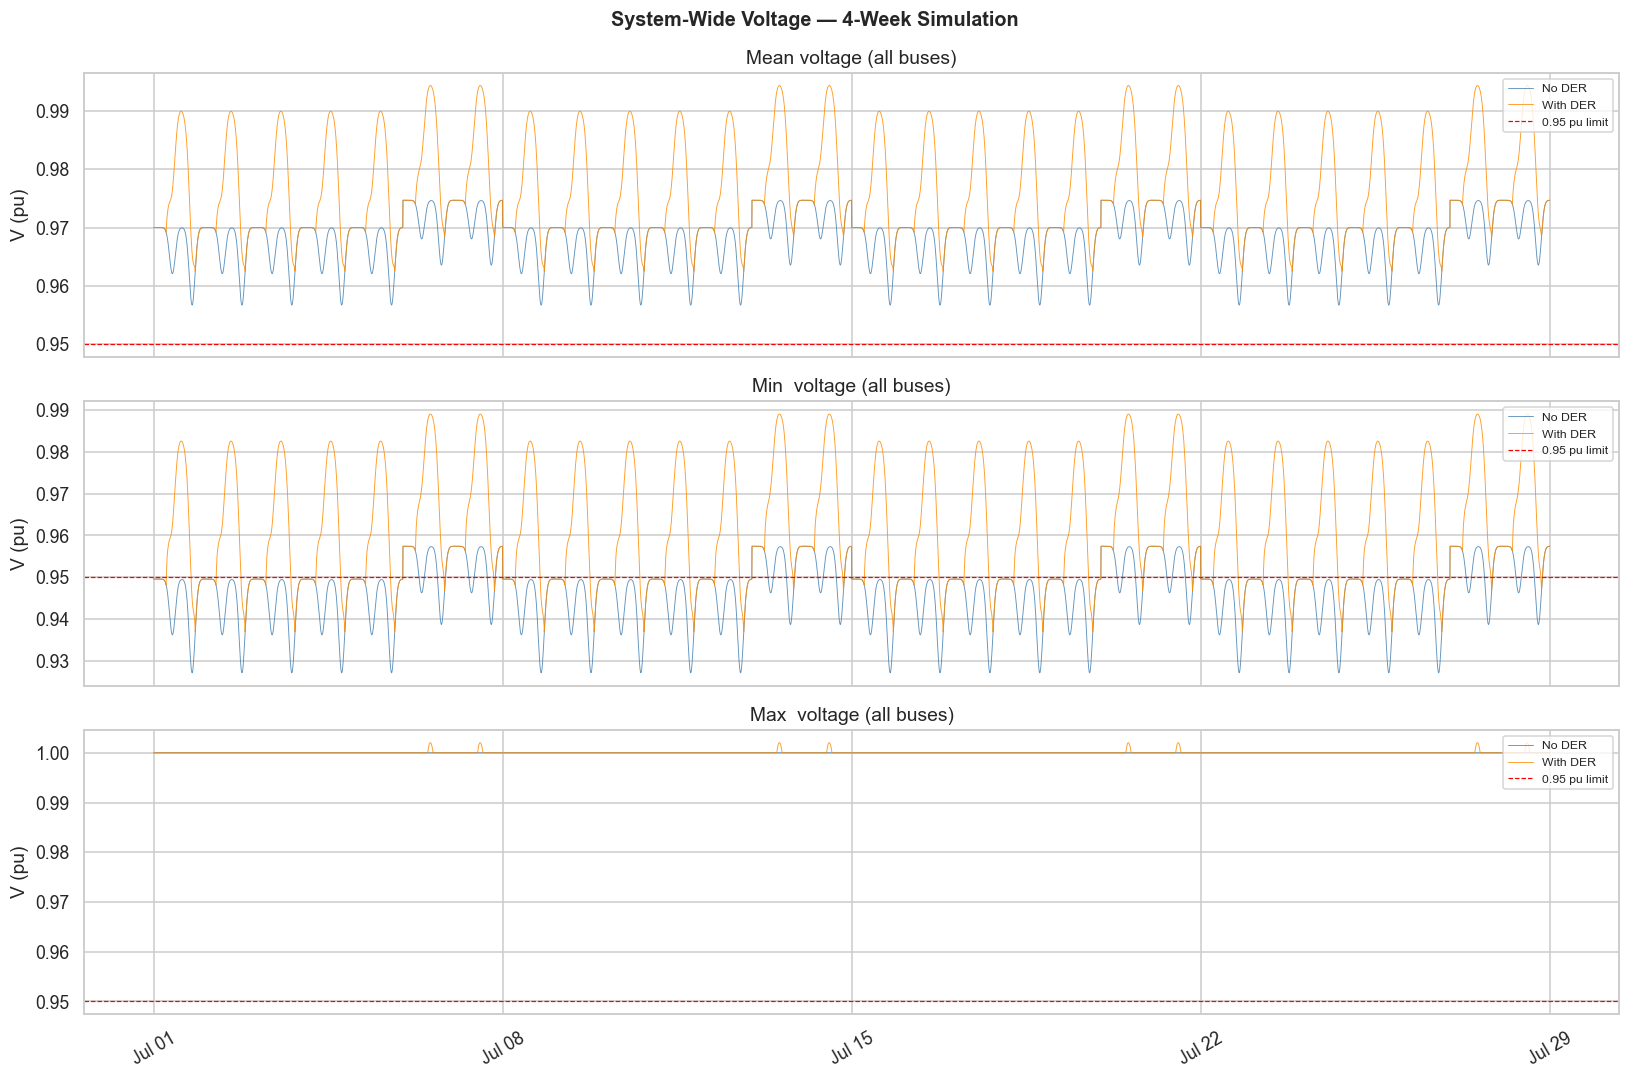

In [6]:
ts = df_der['timestamp']

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

metrics = [
    ('Mean voltage (all buses)',  V_der.mean(axis=1),  V_nder.mean(axis=1)),
    ('Min  voltage (all buses)',  V_der.min(axis=1),   V_nder.min(axis=1)),
    ('Max  voltage (all buses)',  V_der.max(axis=1),   V_nder.max(axis=1)),
]

for ax, (title, ser_d, ser_nd) in zip(axes, metrics):
    ax.plot(ts, ser_nd, color='steelblue',  lw=0.6, alpha=0.85, label='No DER')
    ax.plot(ts, ser_d,  color='darkorange', lw=0.6, alpha=0.85, label='With DER')
    ax.set_ylabel('V (pu)')
    ax.set_title(title)
    ax.axhline(0.95, color='red', ls='--', lw=0.8, label='0.95 pu limit')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle('System-Wide Voltage — 4-Week Simulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4  Individual Bus Voltage — Key Buses

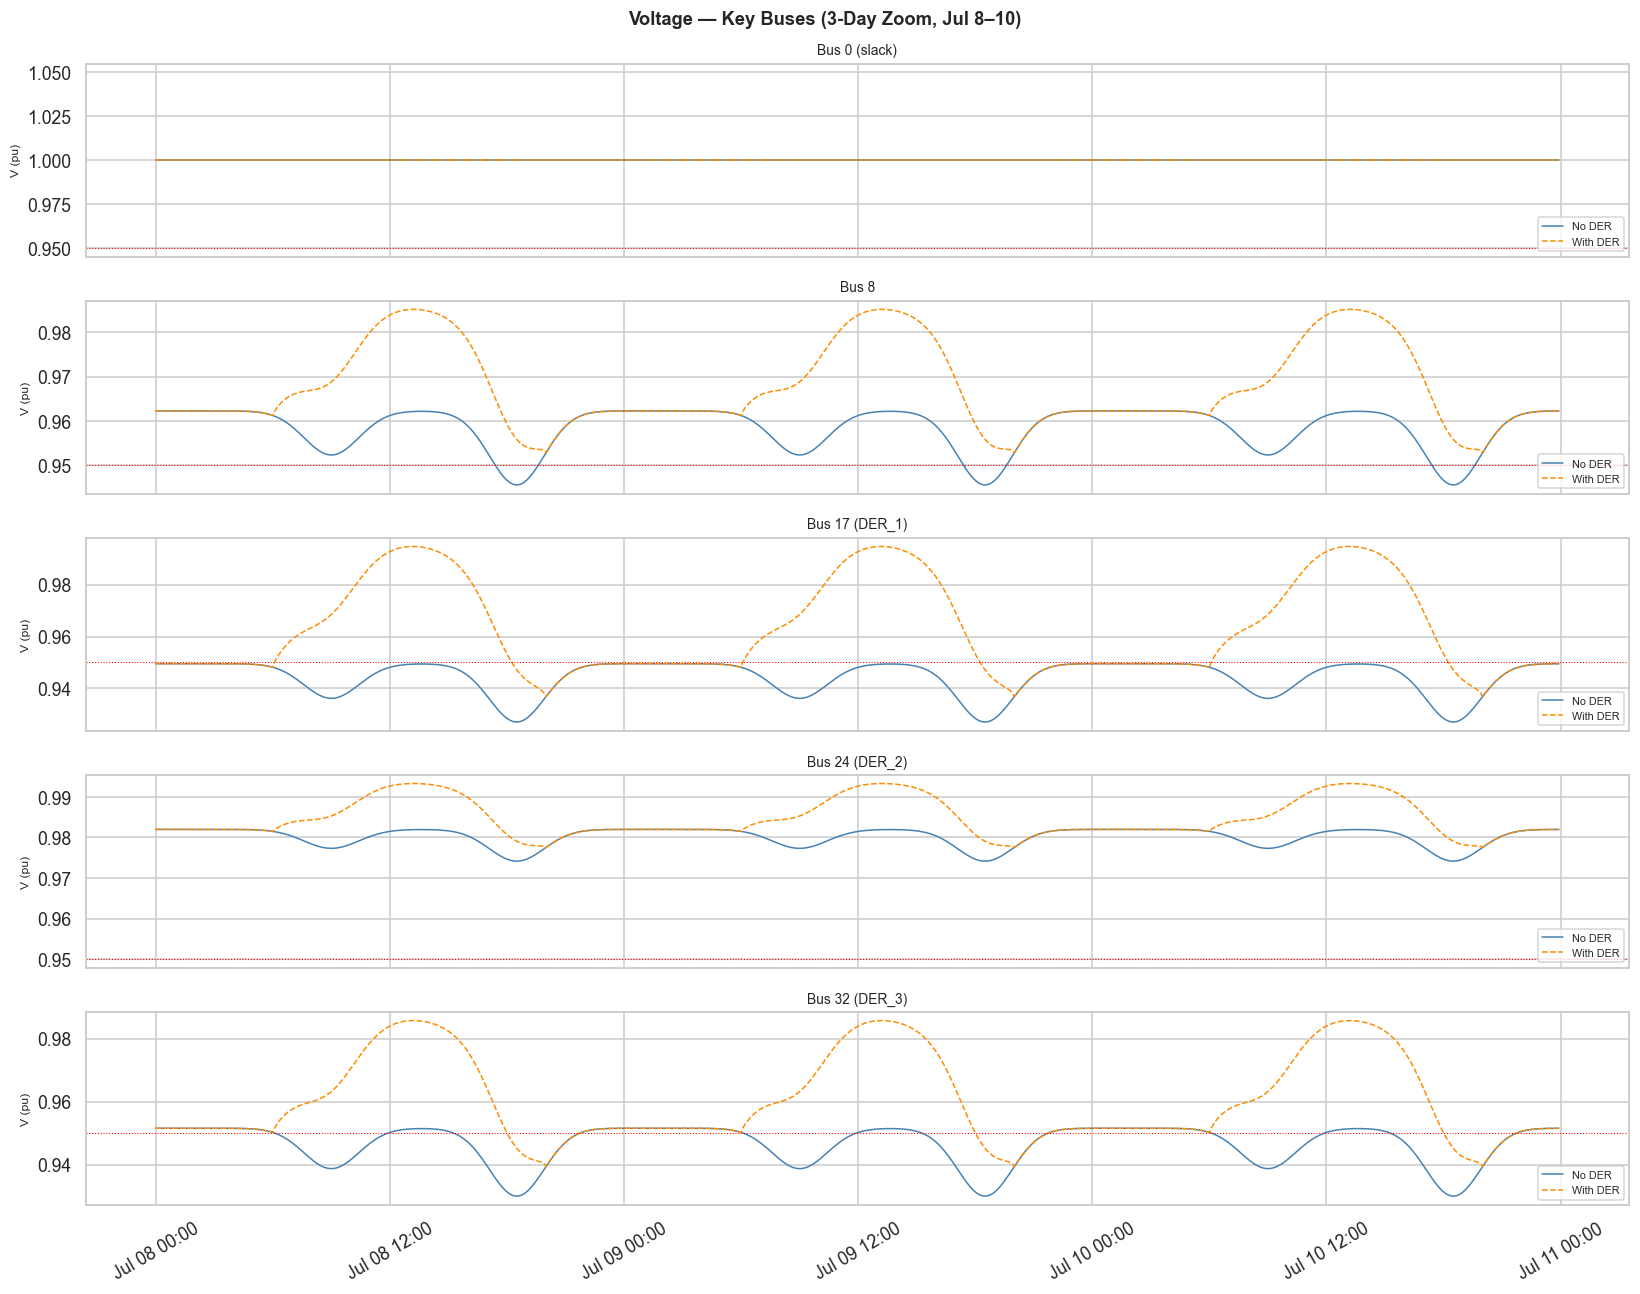

In [7]:
key_buses = [0, 8, 17, 24, 32]   # slack, end-of-main-feeder, all 3 DER buses
labels    = ['Bus 0 (slack)', 'Bus 8', 'Bus 17 (DER_1)', 'Bus 24 (DER_2)', 'Bus 32 (DER_3)']

# Show 3 days for clarity
mask = (ts >= '2024-07-08') & (ts < '2024-07-11')
ts_zoom = ts[mask]

fig, axes = plt.subplots(len(key_buses), 1, figsize=(15, 12), sharex=True)

for ax, bus, lbl in zip(axes, key_buses, labels):
    ax.plot(ts_zoom, V_nder[bus][mask].values, color='steelblue',  lw=1.0, label='No DER')
    ax.plot(ts_zoom, V_der[bus][mask].values,  color='darkorange', lw=1.0, label='With DER', ls='--')
    ax.set_ylabel('V (pu)', fontsize=8)
    ax.set_title(lbl, fontsize=9)
    ax.axhline(0.95, color='red', ls=':', lw=0.7)
    ax.legend(loc='lower right', fontsize=7)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle('Voltage — Key Buses (3-Day Zoom, Jul 8–10)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5  Voltage Difference Heatmap  (With DER − No DER)

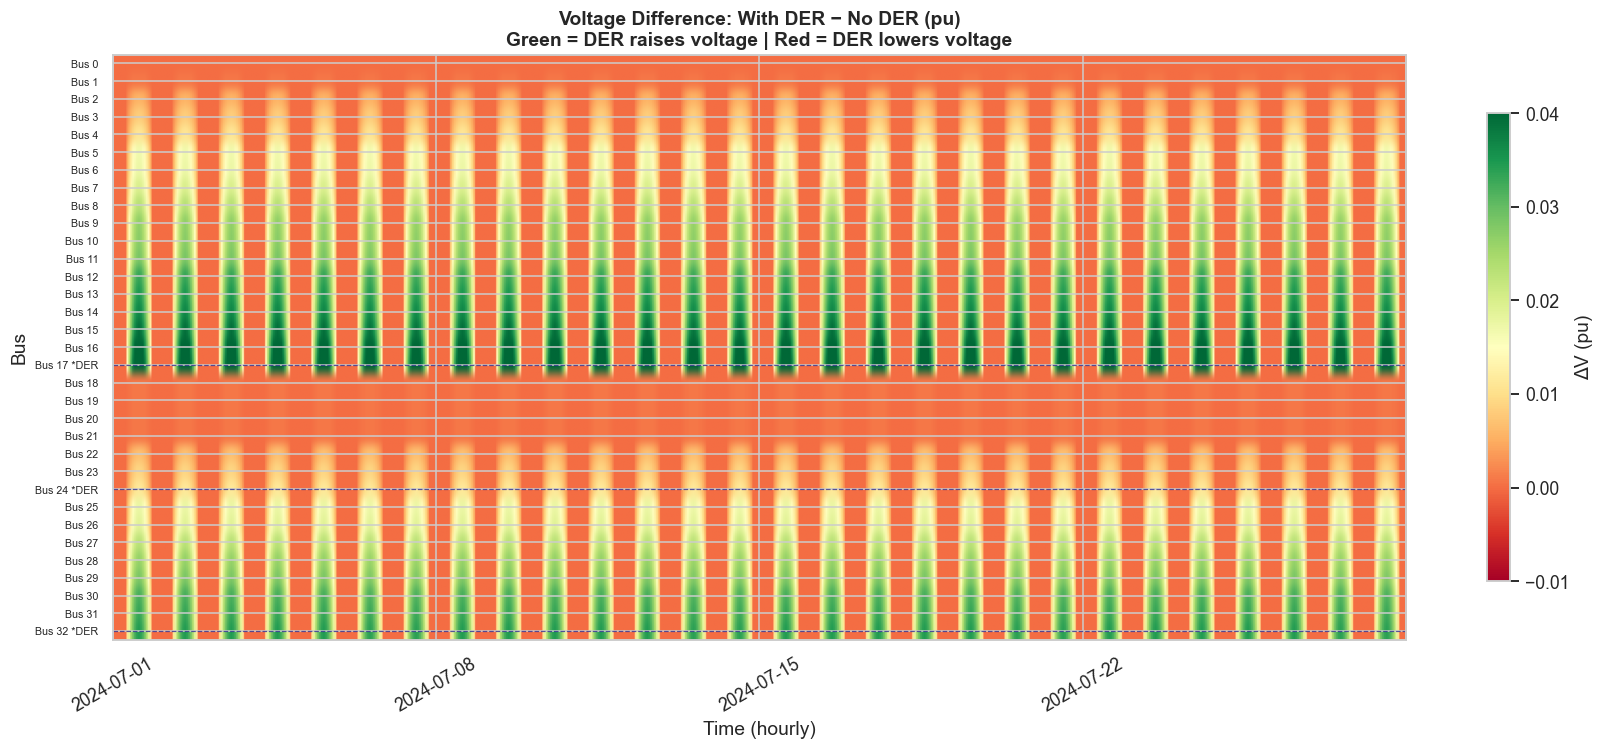

In [8]:
# Compute delta V: shape (n_steps, 33)
delta_V = (V_der - V_nder).values   # positive = DER raises voltage

# Downsample to hourly averages for readability
hours_idx = np.arange(0, len(ts), 12)   # every 12 × 5min = 1 hour
delta_hr  = delta_V[hours_idx, :]       # (672 hours, 33 buses)
ts_hr     = ts.iloc[hours_idx]

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(delta_hr.T, aspect='auto', cmap='RdYlGn',
               vmin=-0.01, vmax=0.04,
               extent=[0, len(ts_hr), 32.5, -0.5])

# Mark DER bus rows
for b in DER_BUSES:
    ax.axhline(b, color='navy', lw=0.8, ls='--', alpha=0.6)

# X-axis: week ticks
week_ticks = np.arange(0, len(ts_hr), 24*7)
ax.set_xticks(week_ticks)
ax.set_xticklabels([str(ts_hr.iloc[i].date()) for i in week_ticks], rotation=30)
ax.set_yticks(range(33))
ax.set_yticklabels([f'Bus {b}' + (' *DER' if b in DER_BUSES else '') for b in range(33)], fontsize=7)
ax.set_xlabel('Time (hourly)')
ax.set_ylabel('Bus')
ax.set_title('Voltage Difference: With DER − No DER (pu)\nGreen = DER raises voltage | Red = DER lowers voltage', fontweight='bold')
plt.colorbar(im, ax=ax, label='ΔV (pu)', shrink=0.8)
plt.tight_layout()
plt.show()

## 6  Average Daily Voltage Profile  (by Hour of Day)

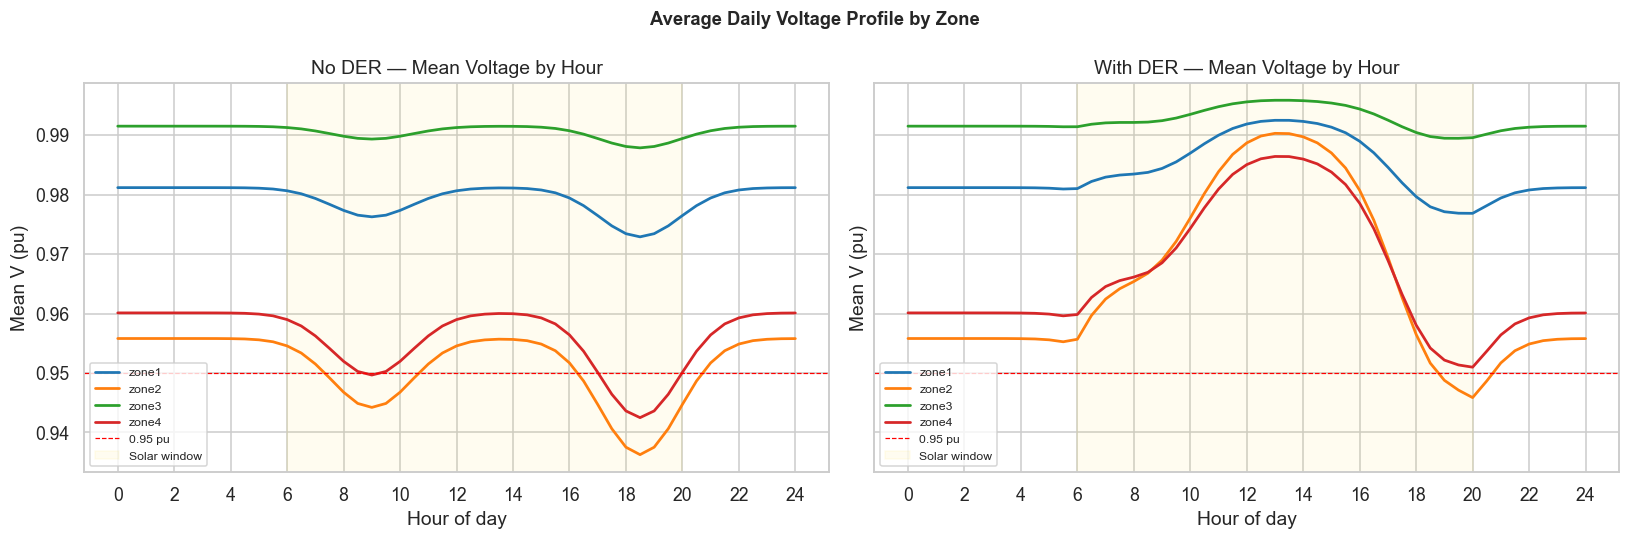

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (df, V, title, color) in zip(axes, [
    (df_nder, V_nder, 'No DER — Mean Voltage by Hour', 'steelblue'),
    (df_der,  V_der,  'With DER — Mean Voltage by Hour', 'darkorange'),
]):
    hour_bins = np.round(df['hour'] * 2) / 2   # round to nearest 30 min
    for zone_name, buses in ZONES.items():
        zone_mean = V[buses].mean(axis=1)       # mean across zone buses
        hourly    = pd.Series(zone_mean.values).groupby(hour_bins.values).mean()
        ax.plot(hourly.index, hourly.values, label=zone_name,
                color=ZONE_COLORS[zone_name], lw=1.8)
    ax.axhline(0.95, color='red', ls='--', lw=0.8, label='0.95 pu')
    ax.axvspan(6, 20, alpha=0.06, color='gold', label='Solar window')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Mean V (pu)')
    ax.set_title(title)
    ax.set_xticks(range(0, 25, 2))
    ax.legend(fontsize=8)

fig.suptitle('Average Daily Voltage Profile by Zone', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7  Voltage Distribution — With vs Without DER

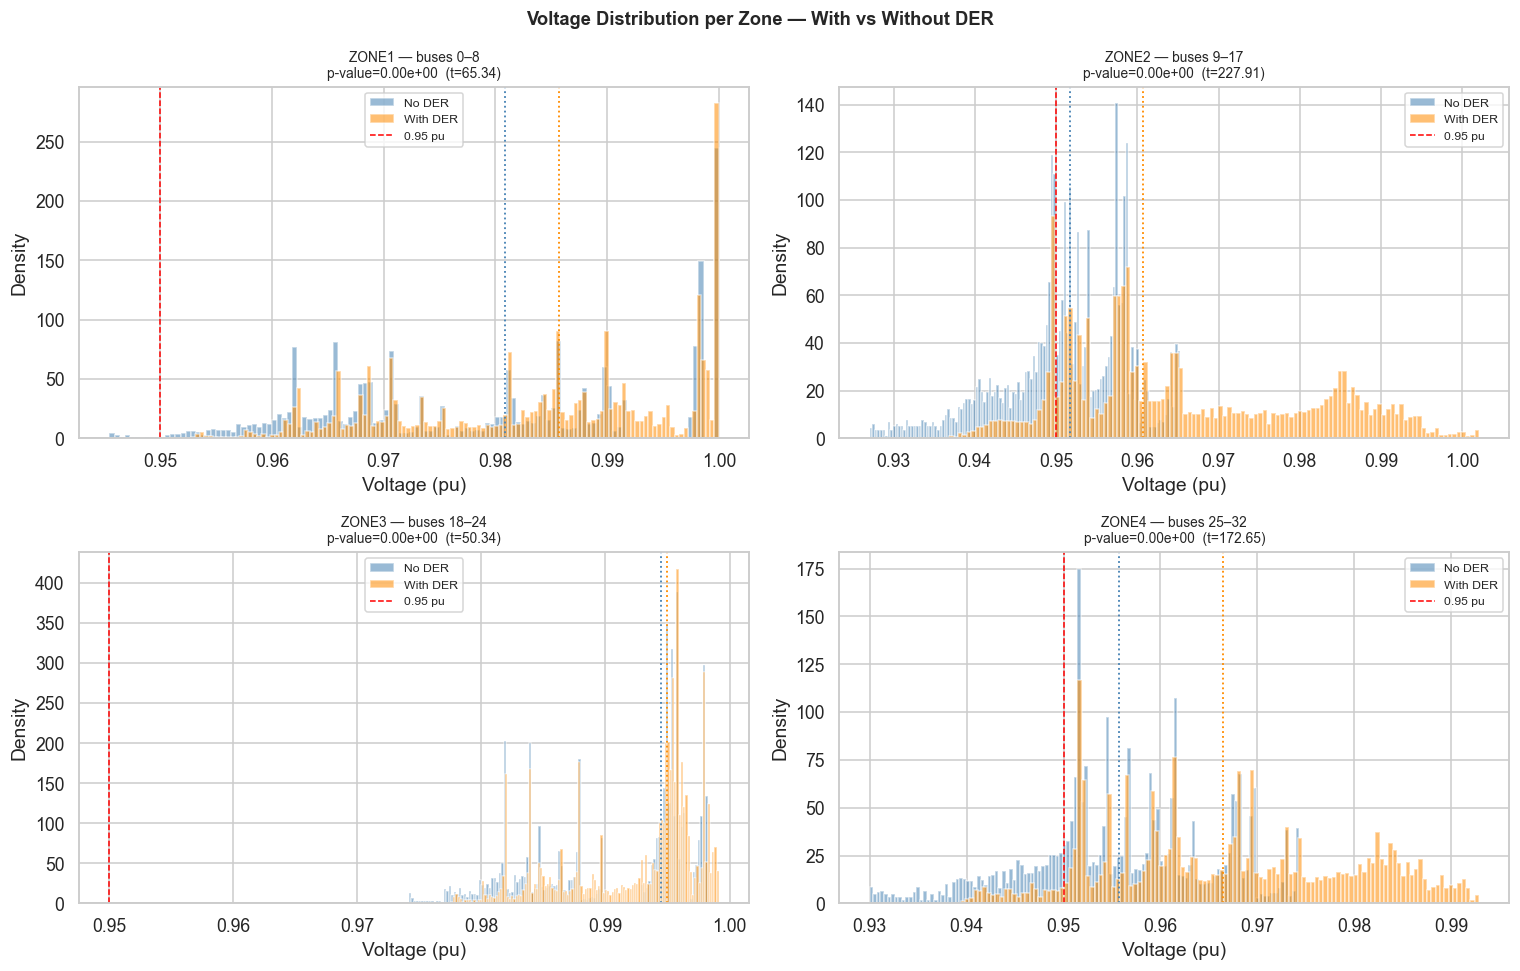

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (zone_name, buses) in zip(axes.flat, ZONES.items()):
    v_nd_flat = V_nder[buses].values.ravel()
    v_d_flat  = V_der[buses].values.ravel()

    ax.hist(v_nd_flat, bins=120, density=True, alpha=0.55,
            color='steelblue', label='No DER')
    ax.hist(v_d_flat,  bins=120, density=True, alpha=0.55,
            color='darkorange', label='With DER')
    ax.axvline(0.95, color='red', ls='--', lw=1, label='0.95 pu')
    ax.axvline(np.median(v_d_flat),  color='darkorange', ls=':',  lw=1.2)
    ax.axvline(np.median(v_nd_flat), color='steelblue',  ls=':',  lw=1.2)

    t_stat, p_val = stats.ttest_ind(v_d_flat, v_nd_flat)
    ax.set_title(f'{zone_name.upper()} — buses {buses[0]}–{buses[-1]}\n'
                 f'p-value={p_val:.2e}  (t={t_stat:.2f})', fontsize=9)
    ax.set_xlabel('Voltage (pu)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Voltage Distribution per Zone — With vs Without DER', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8  Voltage Violation Analysis  (V < 0.95 pu)

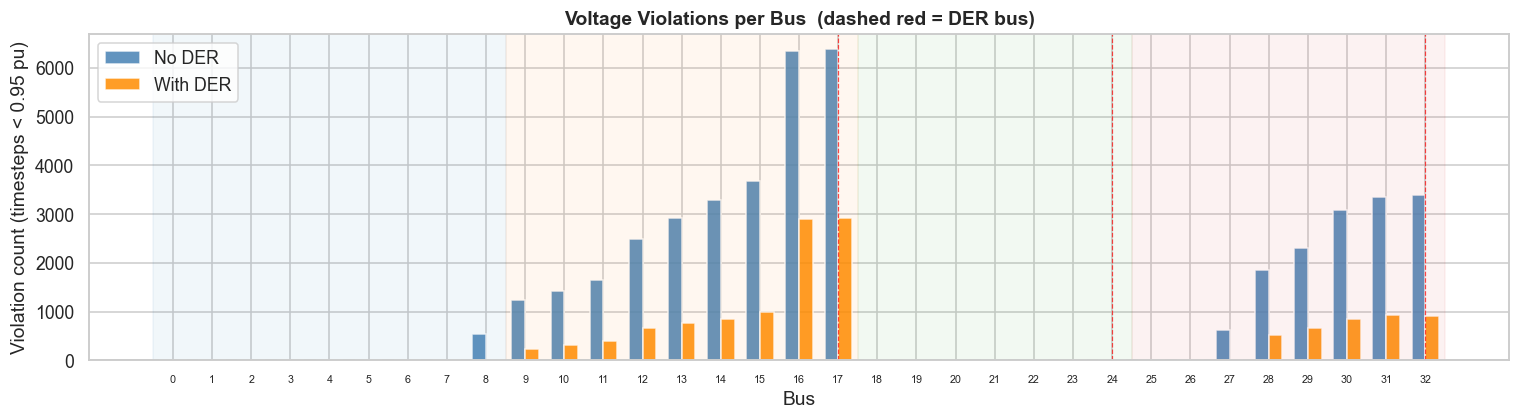

Total violations — No DER : 44,552
Total violations — DER    : 13,920
Reduction                  : 30,632  (68.8%)


In [11]:
viol_nder = (V_nder < 0.95).sum(axis=0)   # violation count per bus
viol_der  = (V_der  < 0.95).sum(axis=0)

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(33)
w = 0.35
ax.bar(x - w/2, viol_nder, w, label='No DER',   color='steelblue',  alpha=0.85)
ax.bar(x + w/2, viol_der,  w, label='With DER', color='darkorange', alpha=0.85)

# Zone shading
zone_ranges = [(0,8,'#1f77b4'),(9,17,'#ff7f0e'),(18,24,'#2ca02c'),(25,32,'#d62728')]
for start, end, c in zone_ranges:
    ax.axvspan(start-0.5, end+0.5, alpha=0.06, color=c)

for b in DER_BUSES:
    ax.axvline(b, color='red', ls='--', lw=0.8, alpha=0.7)

ax.set_xticks(range(33))
ax.set_xticklabels([str(b) for b in range(33)], fontsize=7)
ax.set_xlabel('Bus')
ax.set_ylabel('Violation count (timesteps < 0.95 pu)')
ax.set_title('Voltage Violations per Bus  (dashed red = DER bus)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total violations — No DER : {int(viol_nder.sum()):,}')
print(f'Total violations — DER    : {int(viol_der.sum()):,}')
print(f'Reduction                  : {int(viol_nder.sum() - viol_der.sum()):,}  ({(1 - viol_der.sum()/max(viol_nder.sum(),1))*100:.1f}%)')

## 9  Active Power (P_MW) — System-Level Comparison

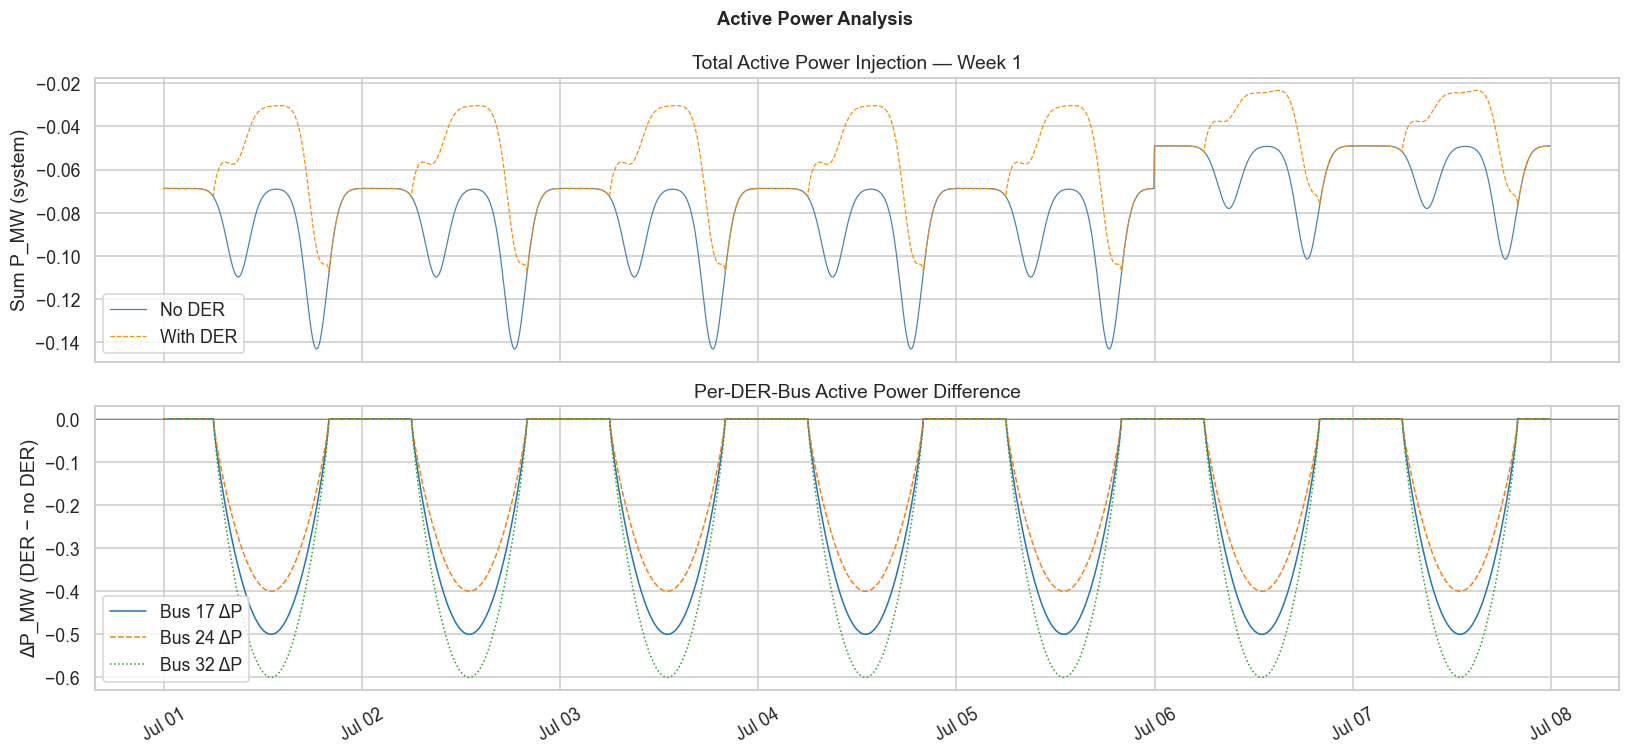

In [12]:
# Total injected power at each timestep (sum of all bus P_MW)
# In pandapower res_bus, p_mw is net injection; negative = net load
p_total_der  = P_der.sum(axis=1)
p_total_nder = P_nder.sum(axis=1)

mask_week1 = (ts >= '2024-07-01') & (ts < '2024-07-08')

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(ts[mask_week1], p_total_nder[mask_week1].values, color='steelblue',  lw=0.8, label='No DER')
axes[0].plot(ts[mask_week1], p_total_der[mask_week1].values,  color='darkorange', lw=0.8, label='With DER', ls='--')
axes[0].set_ylabel('Sum P_MW (system)')
axes[0].set_title('Total Active Power Injection — Week 1')
axes[0].legend()

# Per-DER-bus power
for bus, style in zip(DER_BUSES, ['-','--',':']):
    axes[1].plot(ts[mask_week1],
                 (P_der[bus] - P_nder[bus])[mask_week1].values,
                 lw=1.0, ls=style, label=f'Bus {bus} ΔP')
axes[1].axhline(0, color='grey', lw=0.6)
axes[1].set_ylabel('ΔP_MW (DER − no DER)')
axes[1].set_title('Per-DER-Bus Active Power Difference')
axes[1].legend()

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle('Active Power Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10  Correlation Heatmap — Voltage Across Buses  (With DER)

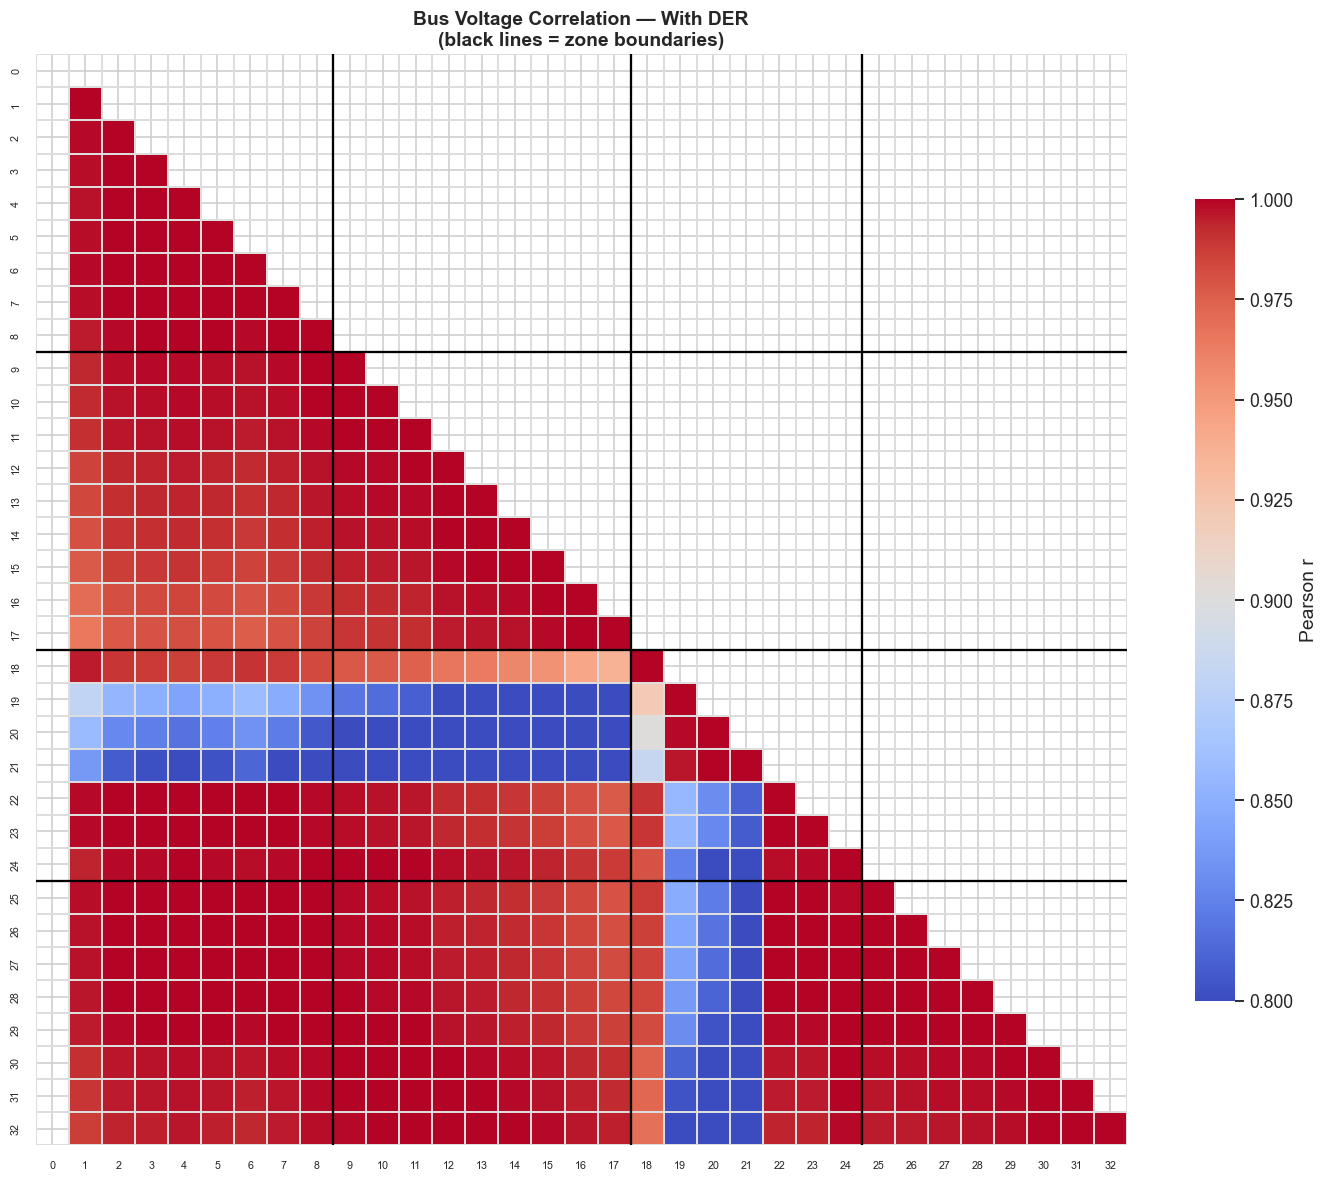

In [13]:
corr = V_der.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, cmap='coolwarm', vmin=0.8, vmax=1.0,
            mask=mask_upper, square=True,
            xticklabels=range(33), yticklabels=range(33),
            linewidths=0.3, linecolor='#dddddd',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.7})

# Zone grid lines
for boundary in [9, 18, 25]:
    ax.axhline(boundary, color='black', lw=1.5)
    ax.axvline(boundary, color='black', lw=1.5)

ax.set_title('Bus Voltage Correlation — With DER\n(black lines = zone boundaries)', fontweight='bold')
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()

## 11  Zone-Level Mean Voltage — Side-by-Side Box Plot

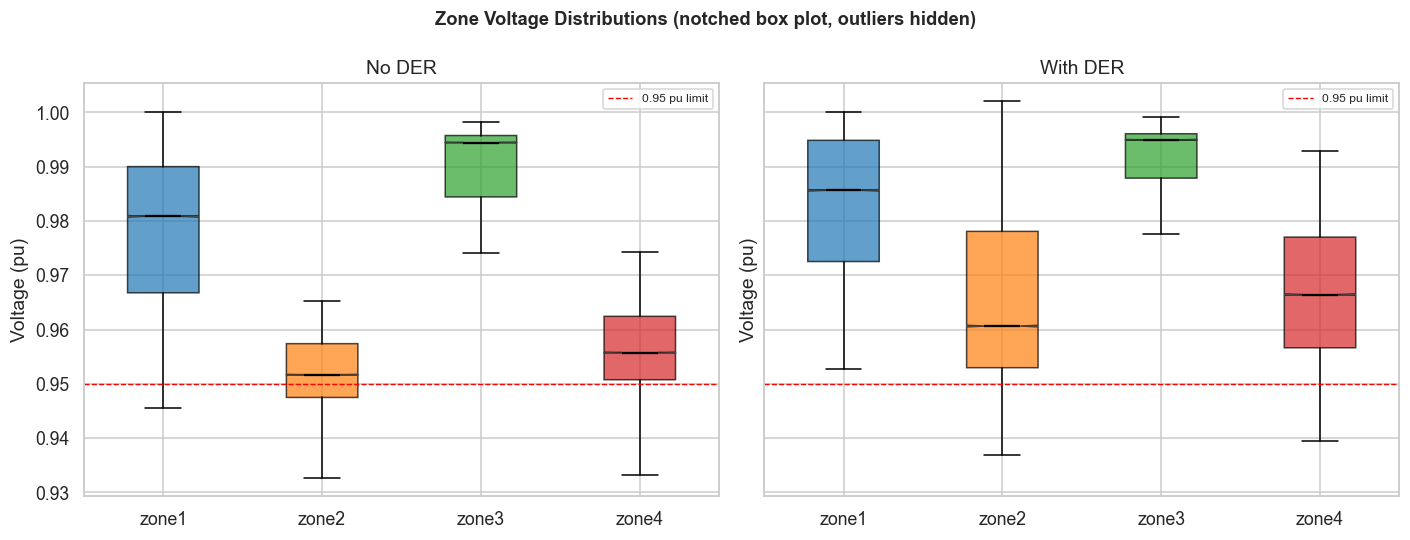

In [14]:
box_data_nder = {z: V_nder[buses].values.ravel() for z, buses in ZONES.items()}
box_data_der  = {z: V_der[buses].values.ravel()  for z, buses in ZONES.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (box_data, title, color) in zip(axes, [
    (box_data_nder, 'No DER', 'steelblue'),
    (box_data_der,  'With DER', 'darkorange'),
]):
    positions = range(1, 5)
    bp = ax.boxplot(list(box_data.values()), positions=positions,
                    patch_artist=True, notch=True, showfliers=False,
                    medianprops=dict(color='black', lw=1.5))
    for patch, c in zip(bp['boxes'], ZONE_COLORS.values()):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(0.95, color='red', ls='--', lw=0.9, label='0.95 pu limit')
    ax.set_xticks(positions)
    ax.set_xticklabels(list(ZONES.keys()))
    ax.set_ylabel('Voltage (pu)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Zone Voltage Distributions (notched box plot, outliers hidden)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 12  DER Bus Deep Dive — Voltage + Solar Window

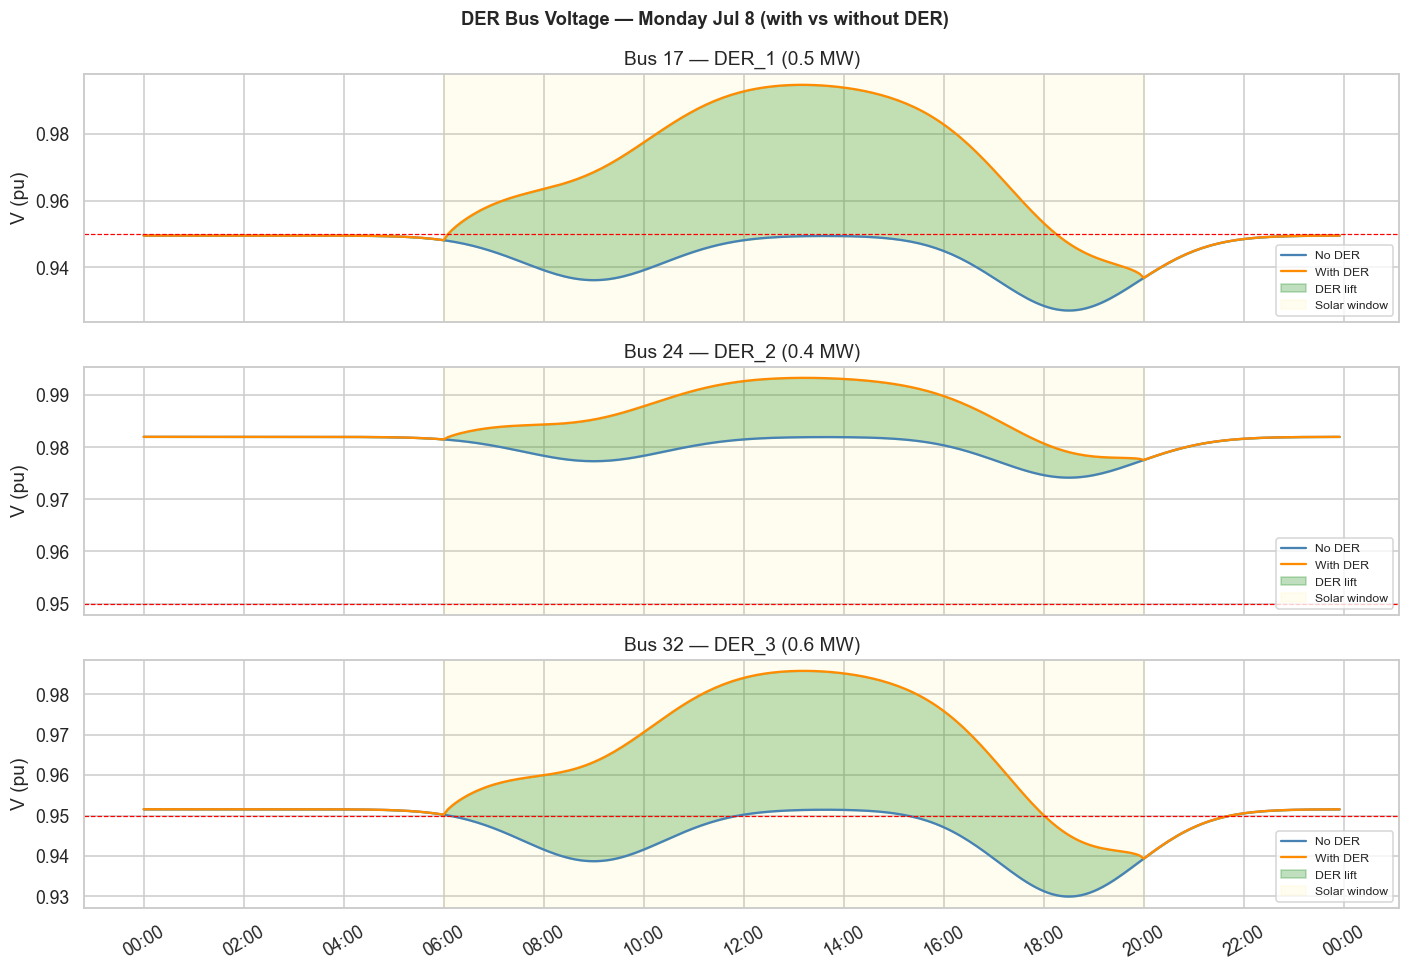

In [15]:
# One representative day (Mon Jul 8)
mask_day = (ts >= '2024-07-08') & (ts < '2024-07-09')
ts_day   = ts[mask_day]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

der_caps = {17: 0.5, 24: 0.4, 32: 0.6}
der_labels = {17: 'Bus 17 — DER_1 (0.5 MW)', 24: 'Bus 24 — DER_2 (0.4 MW)', 32: 'Bus 32 — DER_3 (0.6 MW)'}

for ax, bus in zip(axes, DER_BUSES):
    ax.plot(ts_day, V_nder[bus][mask_day].values, color='steelblue',  lw=1.5, label='No DER')
    ax.plot(ts_day, V_der[bus][mask_day].values,  color='darkorange', lw=1.5, label='With DER')
    ax.fill_between(ts_day,
                    V_nder[bus][mask_day].values,
                    V_der[bus][mask_day].values,
                    alpha=0.25, color='green', label='DER lift')
    ax.axhline(0.95, color='red', ls='--', lw=0.8)
    ax.axvspan(pd.Timestamp('2024-07-08 06:00'), pd.Timestamp('2024-07-08 20:00'),
               alpha=0.06, color='gold', label='Solar window')
    ax.set_ylabel('V (pu)')
    ax.set_title(der_labels[bus])
    ax.legend(loc='lower right', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle('DER Bus Voltage — Monday Jul 8 (with vs without DER)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 13  Reactive Power (Q_MVAR) — Zone Means Over Time

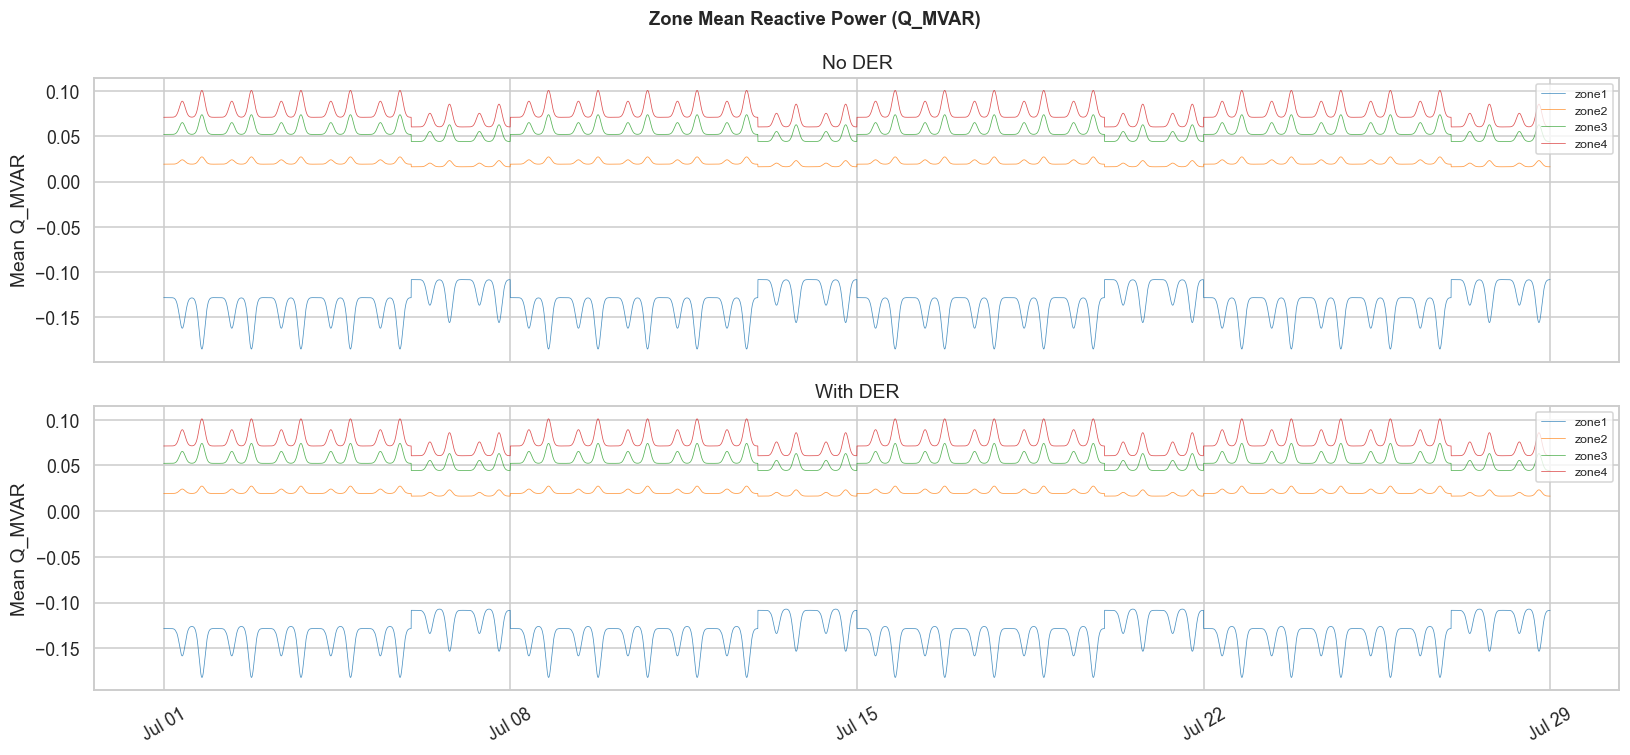

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

for zone_name, buses in ZONES.items():
    q_nd = Q_nder[buses].mean(axis=1)
    q_d  = Q_der[buses].mean(axis=1)
    c    = ZONE_COLORS[zone_name]
    axes[0].plot(ts, q_nd, lw=0.5, color=c, alpha=0.8, label=zone_name)
    axes[1].plot(ts, q_d,  lw=0.5, color=c, alpha=0.8, label=zone_name)

axes[0].set_ylabel('Mean Q_MVAR')
axes[0].set_title('No DER')
axes[0].legend(loc='upper right', fontsize=8)
axes[1].set_ylabel('Mean Q_MVAR')
axes[1].set_title('With DER')
axes[1].legend(loc='upper right', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle('Zone Mean Reactive Power (Q_MVAR)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 14  Summary — Key Takeaways

In [17]:
mean_v_nder  = V_nder.values.mean()
mean_v_der   = V_der.values.mean()
min_v_nder   = V_nder.values.min()
min_v_der    = V_der.values.min()
viol_nder_t  = int((V_nder < 0.95).values.sum())
viol_der_t   = int((V_der  < 0.95).values.sum())
max_delta    = float((V_der - V_nder).values.max())
max_delta_bus = int((V_der - V_nder).values.max(axis=0).argmax())

print('=' * 55)
print('SIMULATION EDA — KEY FINDINGS')
print('=' * 55)
print(f'Timesteps            : {len(ts):,}  (4 weeks @ 5-min)')
print()
print(f'Mean voltage  No DER : {mean_v_nder:.5f} pu')
print(f'Mean voltage  DER    : {mean_v_der:.5f} pu  (Δ {mean_v_der-mean_v_nder:+.5f})')
print()
print(f'Min  voltage  No DER : {min_v_nder:.5f} pu')
print(f'Min  voltage  DER    : {min_v_der:.5f} pu')
print()
print(f'Violations <0.95 pu  No DER : {viol_nder_t:,}')
print(f'Violations <0.95 pu  DER    : {viol_der_t:,}  ({(1-viol_der_t/max(viol_nder_t,1))*100:.1f}% reduction)')
print()
print(f'Largest voltage lift : +{max_delta:.5f} pu at Bus {max_delta_bus}')
print()
print('DER effect is strongest during 06:00–20:00 (solar window)')
print('At night both datasets are IDENTICAL (no DER injection)')
print('=' * 55)

SIMULATION EDA — KEY FINDINGS
Timesteps            : 8,064  (4 weeks @ 5-min)

Mean voltage  No DER : 0.96837 pu
Mean voltage  DER    : 0.97646 pu  (Δ +0.00809)

Min  voltage  No DER : 0.92706 pu
Min  voltage  DER    : 0.93684 pu

Violations <0.95 pu  No DER : 44,552
Violations <0.95 pu  DER    : 13,920  (68.8% reduction)

Largest voltage lift : +0.04542 pu at Bus 17

DER effect is strongest during 06:00–20:00 (solar window)
At night both datasets are IDENTICAL (no DER injection)


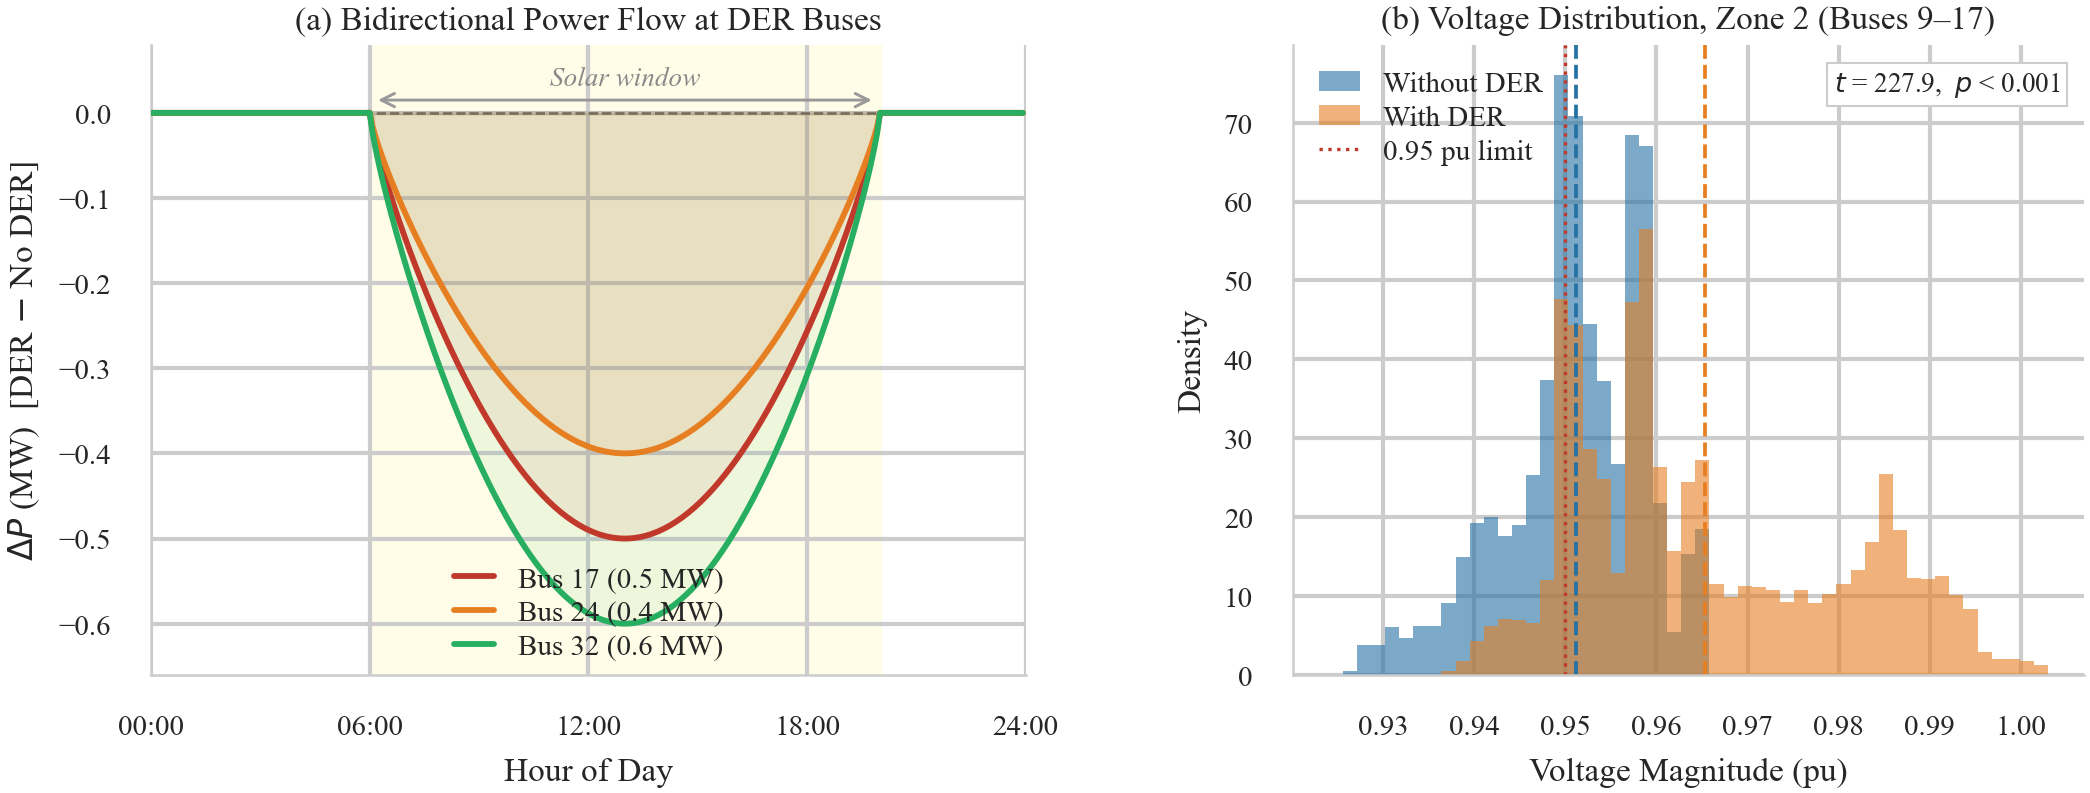

Saved: fig1_der_impact.pdf / .png


In [20]:
# ─── FIGURE 1: IEEE-Style — DER Impact (2-panel) ─────────────────────────────
# Drop the suptitle entirely — caption goes in LaTeX, not in the figure.
# IEEE single-column width = 3.5 in, double-column = 7.16 in
# Use double-column width here since it has two panels.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats

# ── IEEE rcParams ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'        : 'Times New Roman',
    'font.size'          : 8,
    'axes.titlesize'     : 8,
    'axes.labelsize'     : 8,
    'xtick.labelsize'    : 7,
    'ytick.labelsize'    : 7,
    'legend.fontsize'    : 7,
    'axes.linewidth'     : 0.6,
    'xtick.major.width'  : 0.6,
    'ytick.major.width'  : 0.6,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'lines.linewidth'    : 1.2,
    'figure.dpi'         : 300,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.02,
})

DER_BUSES  = [17, 24, 32]
DER_CAPS   = {17: '0.5 MW', 24: '0.4 MW', 32: '0.6 MW'}
DER_COLORS = {17: '#c0392b', 24: '#e67e22', 32: '#27ae60'}
ZONE2_BUSES = list(range(9, 18))

# ── Pre-compute avg 24h ΔP ────────────────────────────────────────────────────
def avg_24h(df, col):
    d = df.copy()
    d['hf'] = d['timestamp'].dt.hour + d['timestamp'].dt.minute / 60
    return d.groupby('hf')[col].mean()

delta_P = {}
for bus in DER_BUSES:
    col = f'P_bus{bus}'
    delta_P[bus] = avg_24h(df_der, col) - avg_24h(df_nder, col)

# ── Pre-compute Zone 2 distributions ─────────────────────────────────────────
z2_cols      = [f'V_bus{b}' for b in ZONE2_BUSES]
v_z2_nd      = df_nder[z2_cols].values.flatten()
v_z2_der     = df_der[z2_cols].values.flatten()
t_stat, _    = stats.ttest_ind(v_z2_der, v_z2_nd, equal_var=False)

# ── Figure layout — IEEE double-column width ──────────────────────────────────
fig = plt.figure(figsize=(7.16, 2.8))
gs  = gridspec.GridSpec(
    1, 2,
    width_ratios=[1.05, 0.95],
    left=0.08, right=0.98,
    bottom=0.16, top=0.91,
    wspace=0.32
)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])

# ── Panel A ───────────────────────────────────────────────────────────────────
ax_a.axvspan(6, 20, color='#fffde7', zorder=0)
ax_a.axhline(0, color='#666666', lw=0.6, ls='--', zorder=1)

for bus in DER_BUSES:
    dp = delta_P[bus]
    ax_a.plot(dp.index, dp.values,
              color=DER_COLORS[bus], lw=1.4, zorder=3,
              label=f'Bus {bus} ({DER_CAPS[bus]})')
    ax_a.fill_between(dp.index, dp.values, 0,
                      where=(dp.values < 0),
                      color=DER_COLORS[bus], alpha=0.08, zorder=2)

# Solar window bracket
ax_a.annotate('', xy=(20, 0.015), xytext=(6, 0.015),
              arrowprops=dict(arrowstyle='<->', color='#999999', lw=0.7))
ax_a.text(13, 0.025, 'Solar window', ha='center', va='bottom',
          fontsize=6.5, color='#888888', style='italic')

ax_a.set_xlim(0, 24)
ax_a.set_ylim(-0.66, 0.08)
ax_a.set_xticks([0, 6, 12, 18, 24])
ax_a.set_xticklabels(['00:00', '06:00', '12:00', '18:00', '24:00'])
ax_a.set_xlabel('Hour of Day')
ax_a.set_ylabel(r'$\Delta P$ (MW)  [DER $-$ No DER]')
ax_a.set_title('(a) Bidirectional Power Flow at DER Buses',
               fontsize=8, pad=4)
ax_a.legend(loc='lower center', frameon=False,
            ncol=1, handlelength=1.4,
            borderpad=0, labelspacing=0.25)

# ── Panel B ───────────────────────────────────────────────────────────────────
bins = np.linspace(0.924, 1.003, 52)

ax_b.hist(v_z2_nd,  bins=bins, density=True, alpha=0.60,
          color='#2471a3', label='Without DER', linewidth=0)
ax_b.hist(v_z2_der, bins=bins, density=True, alpha=0.60,
          color='#e67e22', label='With DER',    linewidth=0)

ax_b.axvline(v_z2_nd.mean(),  color='#2471a3', lw=0.9, ls='--')
ax_b.axvline(v_z2_der.mean(), color='#e67e22', lw=0.9, ls='--')
ax_b.axvline(0.95, color='#c0392b', lw=0.8, ls=':',
             label='0.95 pu limit')

ax_b.set_xlabel('Voltage Magnitude (pu)')
ax_b.set_ylabel('Density')
ax_b.set_title('(b) Voltage Distribution, Zone 2 (Buses 9–17)',
               fontsize=8, pad=4)
ax_b.legend(loc='upper left', frameon=False,
            handlelength=1.4, labelspacing=0.25)

# stat box — clean, minimal
ax_b.text(0.97, 0.96,
          f'$t$ = {t_stat:.1f},  $p$ < 0.001',
          transform=ax_b.transAxes,
          ha='right', va='top', fontsize=6.5,
          bbox=dict(boxstyle='square,pad=0.25',
                    facecolor='white',
                    edgecolor='#cccccc',
                    linewidth=0.5))

plt.savefig('fig1_der_impact.pdf')
plt.savefig('fig1_der_impact.png')
plt.show()
print("Saved: fig1_der_impact.pdf / .png")

Zone correlation matrix:
[[0.9993 0.9905 0.9243 0.998 ]
 [0.9905 0.9973 0.8841 0.9951]
 [0.9243 0.8841 0.9066 0.9109]
 [0.998  0.9951 0.9109 0.9986]]


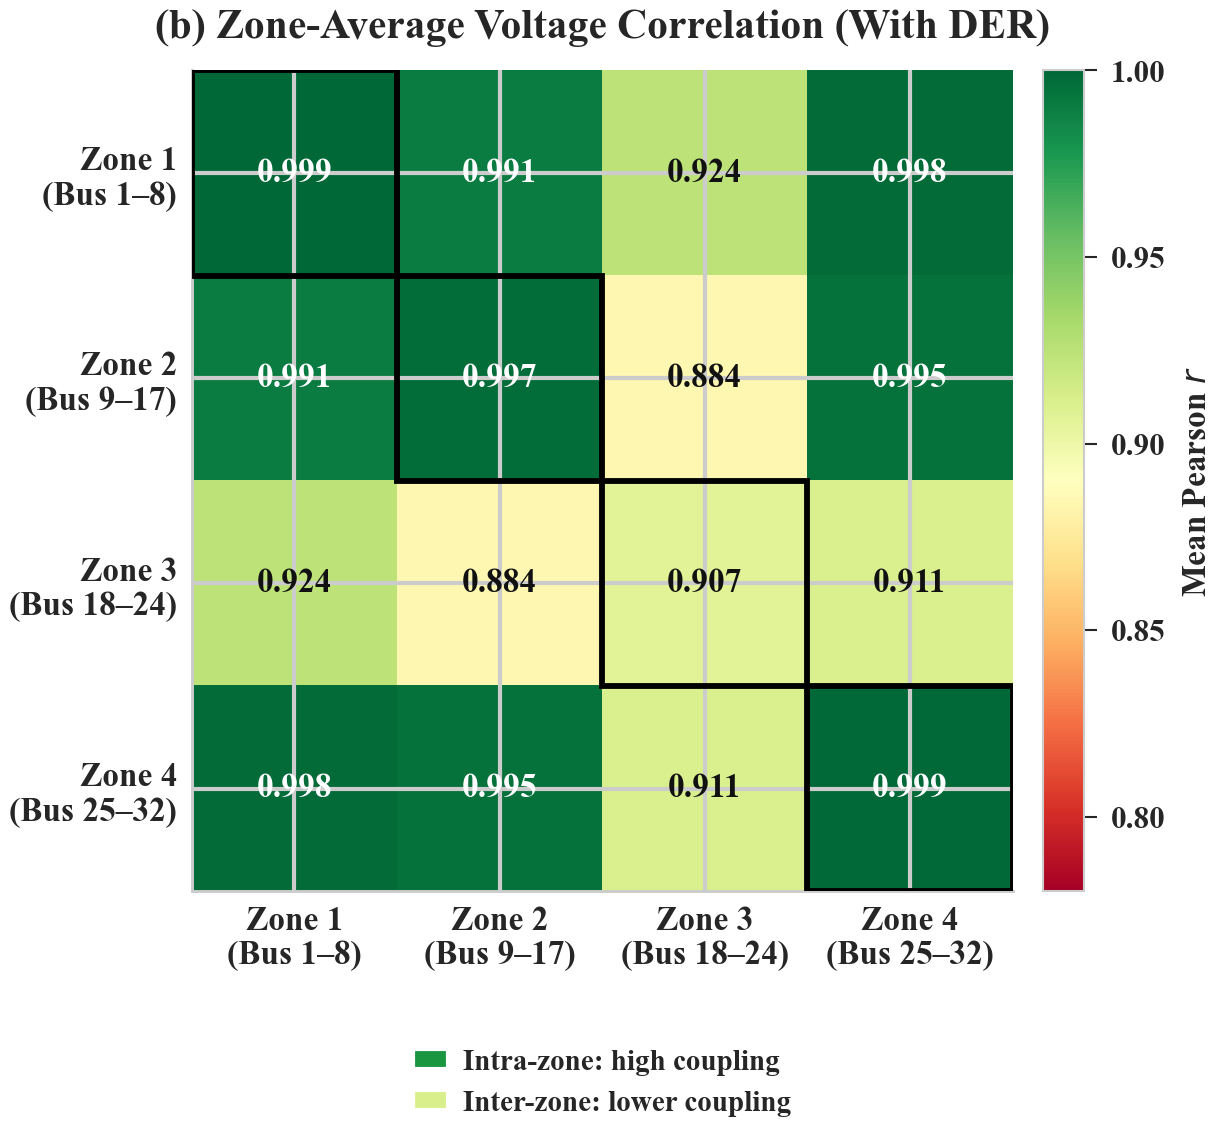

Saved.


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.rcParams.update({
    'font.family'       : 'Times New Roman',
    'font.weight'       : 'bold',
    'axes.labelweight'  : 'bold',
    'axes.titleweight'  : 'bold',
    'font.size'         : 9,
    'axes.titlesize'    : 9,
    'axes.labelsize'    : 9,
    'xtick.labelsize'   : 8.5,
    'ytick.labelsize'   : 8.5,
    'axes.linewidth'    : 0.7,
    'figure.dpi'        : 300,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.03,
})

# ── Zone definitions — exclude Bus 0 (slack bus) ─────────────────────────────
ZONES = {
    'Zone 1\n(Bus 1–8)'  : list(range(1, 9)),
    'Zone 2\n(Bus 9–17)' : list(range(9, 18)),
    'Zone 3\n(Bus 18–24)': list(range(18, 25)),
    'Zone 4\n(Bus 25–32)': list(range(25, 33)),
}

zone_keys = list(ZONES.keys())
n = len(zone_keys)

# ── Extract voltage columns ───────────────────────────────────────────────────
active_buses = [b for b in range(33) if b != 0]
v_cols = [f'V_bus{b}' for b in active_buses]

v_data = df_der[v_cols]
v_data = v_data.loc[:, v_data.std() > 1e-9]

full_corr = v_data.corr().values
bus_index = [int(c.split('bus')[1]) for c in v_data.columns]

# ── Helper function ───────────────────────────────────────────────────────────
def bus_idx(bus_list):
    return [bus_index.index(b) for b in bus_list if b in bus_index]

# ── Build zone correlation matrix ─────────────────────────────────────────────
zone_corr = np.zeros((n, n))

for i, (zi, bi) in enumerate(ZONES.items()):
    idx_i = bus_idx(bi)
    for j, (zj, bj) in enumerate(ZONES.items()):
        idx_j = bus_idx(bj)
        block = full_corr[np.ix_(idx_i, idx_j)]

        if i == j:
            mask = ~np.eye(len(idx_i), dtype=bool)
            vals = block[mask]
            zone_corr[i, j] = vals[~np.isnan(vals)].mean()
        else:
            vals = block.flatten()
            zone_corr[i, j] = vals[~np.isnan(vals)].mean()

print("Zone correlation matrix:")
print(np.round(zone_corr, 4))

# ── Plot figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.4, 3.9))

im = ax.imshow(
    zone_corr,
    cmap='RdYlGn',
    vmin=0.78,
    vmax=1.0,
    aspect='equal',
    interpolation='nearest'
)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.05,
    pad=0.03,
    ticks=[0.80, 0.85, 0.90, 0.95, 1.00]
)

cbar.ax.tick_params(labelsize=7.5, width=0.5, length=3)
cbar.set_label(
    'Mean Pearson $r$',
    fontsize=8,
    labelpad=4,
    fontweight='bold'
)
cbar.outline.set_linewidth(0.5)

# ── Annotate values ───────────────────────────────────────────────────────────
for i in range(n):
    for j in range(n):
        val = zone_corr[i, j]
        color = 'white' if val > 0.96 else '#111111'

        ax.text(
            j, i,
            f'{val:.3f}',
            ha='center',
            va='center',
            fontsize=8,
            color=color,
            fontweight='bold',
            fontfamily='Times New Roman'
        )

# ── Highlight diagonal blocks ────────────────────────────────────────────────
for i in range(n):
    rect = patches.Rectangle(
        (i - 0.5, i - 0.5),
        1,
        1,
        linewidth=1.4,
        edgecolor='black',
        facecolor='none',
        zorder=5
    )
    ax.add_patch(rect)

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.set_xticklabels(
    zone_keys,
    fontsize=8,
    fontweight='bold'
)

ax.set_yticklabels(
    zone_keys,
    fontsize=8,
    fontweight='bold'
)

ax.tick_params(length=0)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    '(b) Zone-Average Voltage Correlation (With DER)',
    fontsize=10,
    pad=8,
    fontweight='bold'
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    patches.Patch(facecolor='#1a9641', label='Intra-zone: high coupling'),
    patches.Patch(facecolor='#d9ef8b', label='Inter-zone: lower coupling'),
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=1,
    frameon=False,
    fontsize=7,
    prop={'weight': 'bold'},
    handlelength=1.2,
    handletextpad=0.5
)

# ── Save outputs ──────────────────────────────────────────────────────────────
plt.tight_layout(pad=0.5)

plt.savefig('fig2_correlation.pdf')
plt.savefig('fig2_correlation.png')

plt.show()

print("Saved.")